In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import gymnasium as gym

In [4]:
env = gym.make("CartPole-v1",
            render_mode='rgb_array')

c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


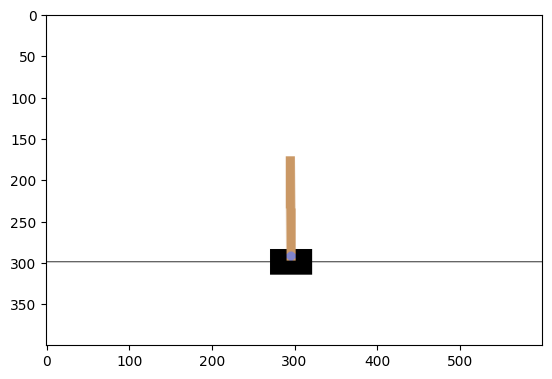

In [5]:
obs,info = env.reset()
img = env.render()
plt.imshow(img)

In [6]:
print(obs)
info

[-0.02530461 -0.0027834  -0.01515689  0.00044215]


{}

In [7]:
class DuelingDQN(nn.Module):

    def __init__(self,n_states,n_actions):
        super().__init__()
        self.n_states = n_states
        self.n_actions = n_actions

        self.shared = nn.Sequential(
            nn.Linear(self.n_states,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU()
        )

        # Value archi le chai calculated the value function (how good is that state not considering action)

        self.value = nn.Sequential(
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
        
        # Advantage archi calculates the advantage of one action over another
        
        self.advantage = nn.Sequential(
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,self.n_actions)
        )

    def forward(self,states):
         
         shared = self.shared(states)

         V = self.value(shared)

         A = self.advantage(shared)

         Q = V + (A - A.mean(dim=1, keepdim=True))

         return Q

    
            
            

In [11]:

class DuelingDQNAgent:

    def __init__(self,env,n_states,n_actions,n_episodes,gamma=0.99,epsilon=1,epsilon_dec=0.9990,epsilon_min=0.01):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.n_episodes = n_episodes
        self.n_actions = n_actions
        self.n_states = n_states
        self.epsilon_dec = epsilon_dec
        self.epsilon_min = epsilon_min

        self.total_steps = 0
        self.lr = 1e-3
        self.memory = deque(maxlen = 100000)
        self.target_update_steps = 500
        self.batch_size = 64
        self.steps = 0
        self.loss_value = 0

        self.reward_per_10epi = []
        self.epino_forplot = []
        self.all_rewards=[]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.online_net = DuelingDQN(n_states,n_actions)
        self.online_net.to(self.device)
        self.target_net = DuelingDQN(n_states,n_actions)
        self.target_net.to(self.device)

        self.optimizer = Adam(self.online_net.parameters(),lr=self.lr)
        self.loss = nn.SmoothL1Loss() 
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()



    def select_action(self,state):

        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:

            state = torch.tensor(state).unsqueeze(0).to(self.device)

            with torch.no_grad():
                q_vals = self.online_net(state)
            return torch.argmax(q_vals).item()


    def replay_buffer(self):
        if len(self.memory) < self.batch_size:
            return
        if self.total_steps % 8 != 0:
            return

        
        batch_data = random.sample(self.memory, self.batch_size)
        states ,actions, rewards, next_states ,done = zip(*batch_data)
        
        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1).to(self.device)

        currentQ = self.online_net(states).gather(1,actions)

        with torch.no_grad():
            nextQ = self.target_net(next_states).max(1,keepdim=True)[0]
            targetQ = rewards + self.gamma * nextQ * (1-done)

        
        loss = self.loss(currentQ,targetQ)
        self.loss_value += loss.item()
        self.optimizer.zero_grad()
        loss.backward() #backprop
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.steps += 1

        if self.steps % self.target_update_steps == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        
    # reward clipping pole ko angle ko basis ma
    def step(self,action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        theta = obs[2]

        reward -= 2.0 * abs(theta)    #soft angle penalty
        return obs, reward, terminated, truncated , info
        

        
    def train(self):
        
        for episode in range(self.n_episodes):
            state,info = env.reset()
            state = state
            total_reward = 0
            done = False

            
            while not done:
                
                action = self.select_action(state)
                next_state, reward, ternimated, truncated, _ = self.step(action)

                done = ternimated or truncated

                total_reward += reward

                self.memory.append((state,action,reward,next_state,done))

                state = next_state

                self.total_steps += 1
                
                self.replay_buffer()

            if episode%10 == 0:
                self.epino_forplot.append(episode)
                avg_reward = np.mean(self.all_rewards[-10:])
                self.reward_per_10epi.append(avg_reward)


            self.epsilon = max(self.epsilon_min,self.epsilon*self.epsilon_dec)
            self.all_rewards.append(total_reward)

                
            if episode%50 ==0:
                print(f"Episode {episode}, Reward {np.mean(self.all_rewards[-50:])}, Epsilon {self.epsilon:.4f}")
        
        
    def plot(self):
        plt.plot(self.epino_forplot, self.reward_per_10epi)
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.title("DQN Training Progress")
        plt.show()


            
    


In [12]:
Agent = DuelingDQNAgent(env,4,2,2500)

In [13]:
Agent.train()

c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ashutosh Thapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Ashutosh Thapa\AppData\Local\Temp\ipykernel_18140\1379461164.py:62: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.tensor(states, dtype=torch.float32).to(self.device)


Episode 0, Reward 6.910956859588623, Epsilon 0.9990
Episode 50, Reward 19.42420196533203, Epsilon 0.9503
Episode 100, Reward 17.236164093017578, Epsilon 0.9039
Episode 150, Reward 16.24306869506836, Epsilon 0.8598
Episode 200, Reward 15.7546968460083, Epsilon 0.8178
Episode 250, Reward 16.496599197387695, Epsilon 0.7779
Episode 300, Reward 20.50006675720215, Epsilon 0.7400
Episode 350, Reward 22.166236877441406, Epsilon 0.7039
Episode 400, Reward 35.695884704589844, Epsilon 0.6695
Episode 450, Reward 37.102760314941406, Epsilon 0.6368
Episode 500, Reward 55.360347747802734, Epsilon 0.6058
Episode 550, Reward 64.57482147216797, Epsilon 0.5762
Episode 600, Reward 80.04635620117188, Epsilon 0.5481
Episode 650, Reward 96.72479248046875, Epsilon 0.5214
Episode 700, Reward 119.29660034179688, Epsilon 0.4959
Episode 750, Reward 165.56040954589844, Epsilon 0.4717
Episode 800, Reward 185.60342407226562, Epsilon 0.4487
Episode 850, Reward 169.2377471923828, Epsilon 0.4268
Episode 900, Reward 221

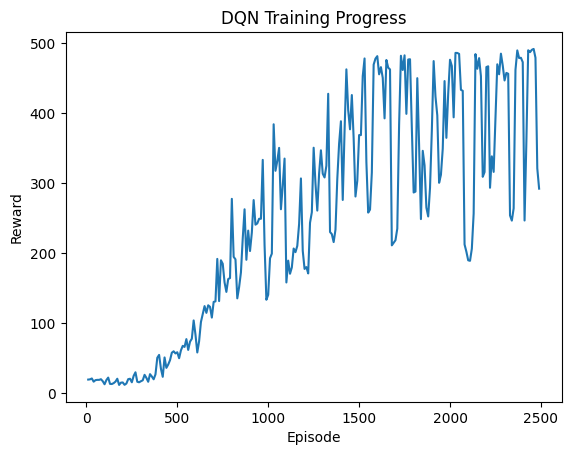

In [14]:
Agent.plot()

In [15]:
torch.save(Agent.online_net.state_dict(), "DuelingDQN-PyTorch-Online_net.pth")

In [17]:
env = gym.make("CartPole-v1",render_mode = "human")
agent = DuelingDQNAgent(env,4,2,2500)
agent.online_net.load_state_dict(torch.load("DuelingDQN-PyTorch-Online_net.pth"))
agent.online_net.eval()

for i in range (3):
    state,_ = env.reset()
    done = False
    total_reward = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    while not done:
        with torch.no_grad():
            state = torch.tensor(state).unsqueeze(0).to(device)
            action = torch.argmax(agent.online_net(state)).item()
        next_state, reward, term, trunc, _ = env.step(action)
        total_reward += reward
        done = term or trunc
        state = next_state
    
    print(f'Total Reward This Episode: {total_reward}')
env.close()
            

Total Reward This Episode: 500.0
Total Reward This Episode: 500.0
Total Reward This Episode: 500.0
